In [1]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

cats = [
    'rec.motorcycles',
    'rec.sport.baseball',
    'comp.graphics',
    'comp.windows.x',
    'talk.politics.mideast',
    'soc.religion.christian',
    'sci.electronics',
    'sci.med'
]

news_df = fetch_20newsgroups(
    subset='all',
    remove=('headers', 'footers', 'quotes'),
    categories=cats,
    random_state=0
)

count_vect = CountVectorizer(
    max_df=0.95,
    max_features=1000,
    min_df=2,
    stop_words='english',
    ngram_range=(1, 2)
)

feat_vect = count_vect.fit_transform(news_df.data)
print('CountVectorizer Shape:', feat_vect.shape)

CountVectorizer Shape: (7862, 1000)


In [2]:
lda = LatentDirichletAllocation(n_components=8, random_state=0)
lda.fit(feat_vect)

,n_components,8
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [4]:
print(lda.components_.shape)
lda.components_

(8, 1000)


array([[2.69030238e+02, 1.87798026e+02, 7.09003824e+01, ...,
        1.22710343e+01, 1.06329639e+02, 7.25995512e+01],
       [1.25091799e-01, 2.46049106e+00, 1.25051902e-01, ...,
        2.80071176e+02, 1.25089783e-01, 5.05669662e+01],
       [1.33978420e+02, 1.25042012e-01, 9.98277256e+01, ...,
        1.25092219e-01, 3.31078261e+01, 1.25028398e-01],
       ...,
       [2.98813886e+01, 1.88071366e+01, 1.14748730e+01, ...,
        1.93022584e+01, 5.29368271e+00, 1.44478198e+01],
       [1.25074899e-01, 1.25105300e-01, 1.25004235e-01, ...,
        1.03576436e+02, 1.25100535e-01, 7.22276359e+01],
       [1.25172284e-01, 1.03967760e+00, 1.25221075e-01, ...,
        5.31740996e+01, 1.25025929e-01, 1.25062991e-01]])

In [5]:
def display_topics(model, feature_names, no_top_words):
    for topic_index, topic in enumerate(model.components_):
        print('Topic #', topic_index)
        topic_word_indexes = topic.argsort()[::-1]
        top_indexes = topic_word_indexes[:no_top_words]
        feature_concat = ' '.join([feature_names[i] for i in top_indexes])
        print(feature_concat)

feature_names = count_vect.get_feature_names_out()
display_topics(lda, feature_names, 15)

Topic # 0
10 year medical health 1993 20 12 disease cancer team patients research number new 11
Topic # 1
don just like know think good time ve does way really people want ll right
Topic # 2
image file jpeg output program gif images format files color entry use bit 03 02
Topic # 3
armenian armenians turkish people said turkey armenia government genocide turks muslim russian greek azerbaijan killed
Topic # 4
israel jews dos jewish israeli dos dos arab state people arabs palestinian adl ed anti peace
Topic # 5
edu com available graphics ftp window use mail data motif software version pub information server
Topic # 6
god people jesus church believe say christ does christian think christians did know bible man
Topic # 7
thanks use using does help like display need problem know server screen windows window program


In [13]:
import pandas as pd
import glob, os
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 700)

path = r'OpinosisDataset1.0\topics'
all_files = glob.glob(os.path.join(path, '*.data'))
len(all_files)

filename_list = []
opinion_text = []

for file_ in all_files:
    filename_list.append(os.path.basename(file_))
    df = pd.read_table(file_, index_col=None, header=0, encoding='latin1')
    opinion_text.append(df.to_string())
    filename = file_.split('\\')[-1]
    filename = filename.split('.')[0]

    filename_list.append(filename)
    opinion_text.append(df.to_string())

document_df = pd.DataFrame({
    'filename': filename_list,
    'opinion_text': opinion_text
})

document_df.head()

,filename,opinion_text
0,accuracy_garmin_nuvi_255W_gps.txt.data,", and is very, very accurate .\n0 but for the most part, we find that the Garmin software provides accurate directions, whereever we intend to go .\n1 This functi..."
1,accuracy_garmin_nuvi_255W_gps,", and is very, very accurate .\n0 but for the most part, we find that the Garmin software provides accurate directions, whereever we intend to go .\n1 This functi..."
2,bathroom_bestwestern_hotel_sfo.txt.data,"The room was not overly big, but clean and very comfortable beds, a great shower and very clean bathrooms .\n0 The second room was smaller, with a very inconvenient bathroom layout, but at least it was quieter and we were able to sleep .\n1 ..."
3,bathroom_bestwestern_hotel_sfo,"The room was not overly big, but clean and very comfortable beds, a great shower and very clean bathrooms .\n0 The second room was smaller, with a very inconvenient bathroom layout, but at least it was quieter and we were able to sleep .\n1 ..."
4,battery-life_amazon_kindle.txt.data,"After I plugged it in to my USB hub on my computer to charge the battery the charging cord design is very clever !\n0 After you have paged tru a 500, page book one, page, at, a, time to get from Chapter 2 to Chapter 15, see how excited you are about a low battery and all the time it took to get there !\n1 ..."


In [14]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

lemmatizer = WordNetLemmatizer()

def LemNormalize(text):
    tokens = word_tokenize(re.sub(r'[^a-zA-Z]', ' ', text.lower()))
    return [lemmatizer.lemmatize(token) for token in tokens]

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vect = TfidfVectorizer(
    tokenizer=LemNormalize,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=0.05,
    max_df=0.85
)

feature_vect = tfidf_vect.fit_transform(document_df['opinion_text'])

In [17]:
from sklearn.cluster import KMeans

km_cluster = KMeans(
    n_clusters=5,
    max_iter=10000,
    random_state=0,
    n_init=10
)

km_cluster.fit(feature_vect)

cluster_label = km_cluster.labels_
cluster_centers = km_cluster.cluster_centers_

In [18]:
document_df['cluster_label'] = cluster_label
document_df.head()

,filename,opinion_text,cluster_label
0,accuracy_garmin_nuvi_255W_gps.txt.data,", and is very, very accurate .\n0 but for the most part, we find that the Garmin software provides accurate directions, whereever we intend to go .\n1 This functi...",4
1,accuracy_garmin_nuvi_255W_gps,", and is very, very accurate .\n0 but for the most part, we find that the Garmin software provides accurate directions, whereever we intend to go .\n1 This functi...",4
2,bathroom_bestwestern_hotel_sfo.txt.data,"The room was not overly big, but clean and very comfortable beds, a great shower and very clean bathrooms .\n0 The second room was smaller, with a very inconvenient bathroom layout, but at least it was quieter and we were able to sleep .\n1 ...",3
3,bathroom_bestwestern_hotel_sfo,"The room was not overly big, but clean and very comfortable beds, a great shower and very clean bathrooms .\n0 The second room was smaller, with a very inconvenient bathroom layout, but at least it was quieter and we were able to sleep .\n1 ...",3
4,battery-life_amazon_kindle.txt.data,"After I plugged it in to my USB hub on my computer to charge the battery the charging cord design is very clever !\n0 After you have paged tru a 500, page book one, page, at, a, time to get from Chapter 2 to Chapter 15, see how excited you are about a low battery and all the time it took to get there !\n1 ...",1


In [19]:
document_df[document_df['cluster_label'] == 0].sort_values(by='filename')

,filename,opinion_text,cluster_label
35,interior_honda_accord_2008,I love the new body style and the interior is a simple pleasure except for the center dash .\n0 ...,0
34,interior_honda_accord_2008.txt.data,I love the new body style and the interior is a simple pleasure except for the center dash .\n0 ...,0
37,interior_toyota_camry_2007,"First of all, the interior has way too many cheap plastic parts like the cheap plastic center piece that houses the clock .\n0 3 blown struts at 30,000 miles, interior trim coming loose and rattling squeaking, stains on paint, and bug splats taking paint off, premature uneven brake wear, on 3rd windsh...",0
36,interior_toyota_camry_2007.txt.data,"First of all, the interior has way too many cheap plastic parts like the cheap plastic center piece that houses the clock .\n0 3 blown struts at 30,000 miles, interior trim coming loose and rattling squeaking, stains on paint, and bug splats taking paint off, premature uneven brake wear, on 3rd windsh...",0


In [20]:
document_df[document_df['cluster_label'] == 1].sort_values(by='filename')

,filename,opinion_text,cluster_label
5,battery-life_amazon_kindle,"After I plugged it in to my USB hub on my computer to charge the battery the charging cord design is very clever !\n0 After you have paged tru a 500, page book one, page, at, a, time to get from Chapter 2 to Chapter 15, see how excited you are about a low battery and all the time it took to get there !\n1 ...",1
4,battery-life_amazon_kindle.txt.data,"After I plugged it in to my USB hub on my computer to charge the battery the charging cord design is very clever !\n0 After you have paged tru a 500, page book one, page, at, a, time to get from Chapter 2 to Chapter 15, see how excited you are about a low battery and all the time it took to get there !\n1 ...",1
7,battery-life_ipod_nano_8gb,short battery life I moved up from an 8gb .\n0 I love this ipod except for the battery life .\n1 ...,1
6,battery-life_ipod_nano_8gb.txt.data,short battery life I moved up from an 8gb .\n0 I love this ipod except for the battery life .\n1 ...,1
9,battery-life_netbook_1005ha,"6GHz 533FSB cpu, glossy display, 3, Cell 23Wh Li, ion Battery , and a 1 .\n0 Not to mention that as of now...",1
8,battery-life_netbook_1005ha.txt.data,"6GHz 533FSB cpu, glossy display, 3, Cell 23Wh Li, ion Battery , and a 1 .\n0 Not to mention that as of now...",1
39,keyboard_netbook_1005ha,", I think the new keyboard rivals the great hp mini keyboards .\n0 Since the battery life difference is minimum, the only reason to upgrade would be to get the better keyboard .\n1 The keyboard is now as good as t...",1
38,keyboard_netbook_1005ha.txt.data,", I think the new keyboard rivals the great hp mini keyboards .\n0 Since the battery life difference is minimum, the only reason to upgrade would be to get the better keyboard .\n1 The keyboard is now as good as t...",1
53,performance_netbook_1005ha,"The Eee Super Hybrid Engine utility lets users overclock or underclock their Eee PC's to boost performance or provide better battery life depending on their immediate requirements .\n0 In Super Performance mode CPU, Z shows the bus speed to increase up to 169 .\n1 One...",1
52,performance_netbook_1005ha.txt.data,"The Eee Super Hybrid Engine utility lets users overclock or underclock their Eee PC's to boost performance or provide better battery life depending on their immediate requirements .\n0 In Super Performance mode CPU, Z shows the bus speed to increase up to 169 .\n1 One...",1


In [21]:
document_df[document_df['cluster_label'] == 2].sort_values(by='filename')

,filename,opinion_text,cluster_label
13,comfort_honda_accord_2008,"Drivers seat not comfortable, the car itself compared to other models of similar class .\n0 ...",2
12,comfort_honda_accord_2008.txt.data,"Drivers seat not comfortable, the car itself compared to other models of similar class .\n0 ...",2
15,comfort_toyota_camry_2007,"Ride seems comfortable and gas mileage fairly good averaging 26 city and 30 open road .\n0 Seats are fine, in fact of all the smaller sedans this is the most comfortable I found for the price as I am 6', 2 and 250# .\n1 Great gas mileage and comfortable on long trips ...",2
14,comfort_toyota_camry_2007.txt.data,"Ride seems comfortable and gas mileage fairly good averaging 26 city and 30 open road .\n0 Seats are fine, in fact of all the smaller sedans this is the most comfortable I found for the price as I am 6', 2 and 250# .\n1 Great gas mileage and comfortable on long trips ...",2
33,gas_mileage_toyota_camry_2007,Ride seems comfortable and gas mileage fairly good averaging 26 city and 30 open road .\n0 ...,2
32,gas_mileage_toyota_camry_2007.txt.data,Ride seems comfortable and gas mileage fairly good averaging 26 city and 30 open road .\n0 ...,2
45,mileage_honda_accord_2008,"It's quiet, get good gas mileage and looks clean inside and out .\n0 The mileage is great, and I've had to get used to stopping less for gas .\n1 Thought gas ...",2
44,mileage_honda_accord_2008.txt.data,"It's quiet, get good gas mileage and looks clean inside and out .\n0 The mileage is great, and I've had to get used to stopping less for gas .\n1 Thought gas ...",2
51,performance_honda_accord_2008,"Very happy with my 08 Accord, performance is quite adequate it has nice looks and is a great long, distance cruiser .\n0 6, 4, 3 eco engine has poor performance and gas mileage of 22 highway .\n1 Overall performance is good but comfort level is poor .\n2 ...",2
50,performance_honda_accord_2008.txt.data,"Very happy with my 08 Accord, performance is quite adequate it has nice looks and is a great long, distance cruiser .\n0 6, 4, 3 eco engine has poor performance and gas mileage of 22 highway .\n1 Overall performance is good but comfort level is poor .\n2 ...",2


In [22]:
document_df[document_df['cluster_label'] == 3].sort_values(by='filename')

,filename,opinion_text,cluster_label
3,bathroom_bestwestern_hotel_sfo,"The room was not overly big, but clean and very comfortable beds, a great shower and very clean bathrooms .\n0 The second room was smaller, with a very inconvenient bathroom layout, but at least it was quieter and we were able to sleep .\n1 ...",3
2,bathroom_bestwestern_hotel_sfo.txt.data,"The room was not overly big, but clean and very comfortable beds, a great shower and very clean bathrooms .\n0 The second room was smaller, with a very inconvenient bathroom layout, but at least it was quieter and we were able to sleep .\n1 ...",3
27,food_holiday_inn_london,The room was packed to capacity with queues at the food buffets .\n0 The over zealous staff cleared our unfinished drinks while we were collecting cooked food and movement around the room with plates was difficult in the crowded circumstances .\n1 ...,3
26,food_holiday_inn_london.txt.data,The room was packed to capacity with queues at the food buffets .\n0 The over zealous staff cleared our unfinished drinks while we were collecting cooked food and movement around the room with plates was difficult in the crowded circumstances .\n1 ...,3
29,food_swissotel_chicago,The food for our event was delicious .\n0 ...,3
28,food_swissotel_chicago.txt.data,The food for our event was delicious .\n0 ...,3
31,free_bestwestern_hotel_sfo,The wine reception is a great idea as it is nice to meet other travellers and great having access to the free Internet access in our room .\n0 They also have a computer available with free internet which is a nice bonus but I didn't find that out till the day before we left but was still able to get on there to check our flight to Vegas the next day .\n1 ...,3
30,free_bestwestern_hotel_sfo.txt.data,The wine reception is a great idea as it is nice to meet other travellers and great having access to the free Internet access in our room .\n0 They also have a computer available with free internet which is a nice bonus but I didn't find that out till the day before we left but was still able to get on there to check our flight to Vegas the next day .\n1 ...,3
41,location_bestwestern_hotel_sfo,"Good Value good location , ideal choice .\n0 Great Location , Nice Rooms , Helpless Concierge\n1 ...",3
40,location_bestwestern_hotel_sfo.txt.data,"Good Value good location , ideal choice .\n0 Great Location , Nice Rooms , Helpless Concierge\n1 ...",3


In [23]:
document_df[document_df['cluster_label'] == 4].sort_values(by='filename')

,filename,opinion_text,cluster_label
1,accuracy_garmin_nuvi_255W_gps,", and is very, very accurate .\n0 but for the most part, we find that the Garmin software provides accurate directions, whereever we intend to go .\n1 This functi...",4
0,accuracy_garmin_nuvi_255W_gps.txt.data,", and is very, very accurate .\n0 but for the most part, we find that the Garmin software provides accurate directions, whereever we intend to go .\n1 This functi...",4
11,buttons_amazon_kindle,"I thought it would be fitting to christen my Kindle with the Stephen King novella UR, so went to the Amazon site on my computer and clicked on the button to buy it .\n0 As soon as I'd clicked the button to confirm my order it appeared on my Kindle almost immediately !\n1 ...",4
10,buttons_amazon_kindle.txt.data,"I thought it would be fitting to christen my Kindle with the Stephen King novella UR, so went to the Amazon site on my computer and clicked on the button to buy it .\n0 As soon as I'd clicked the button to confirm my order it appeared on my Kindle almost immediately !\n1 ...",4
17,directions_garmin_nuvi_255W_gps,You also get upscale features like spoken directions including street names and programmable POIs .\n0 I used to hesitate to go out of my directions but no...,4
16,directions_garmin_nuvi_255W_gps.txt.data,You also get upscale features like spoken directions including street names and programmable POIs .\n0 I used to hesitate to go out of my directions but no...,4
19,display_garmin_nuvi_255W_gps,"3 quot widescreen display was a bonus .\n0 This made for smoother graphics on the 255w of the vehicle moving along displayed roads, where the 750's display was more of a jerky movement .\n1 ...",4
18,display_garmin_nuvi_255W_gps.txt.data,"3 quot widescreen display was a bonus .\n0 This made for smoother graphics on the 255w of the vehicle moving along displayed roads, where the 750's display was more of a jerky movement .\n1 ...",4
21,eyesight-issues_amazon_kindle,"It feels as easy to read as the K1 but doesn't seem any crisper to my eyes .\n0 the white is really GREY, and to avoid considerable eye, strain I had to refresh pages every other page .\n1 The dream has always been a portable electronic device that could hold a ton of reading material, automate subscriptions and fa...",4
20,eyesight-issues_amazon_kindle.txt.data,"It feels as easy to read as the K1 but doesn't seem any crisper to my eyes .\n0 the white is really GREY, and to avoid considerable eye, strain I had to refresh pages every other page .\n1 The dream has always been a portable electronic device that could hold a ton of reading material, automate subscriptions and fa...",4


In [24]:
from sklearn.cluster import KMeans

km_cluster = KMeans(n_clusters=3, max_iter=10000, random_state=0, n_init=10)
km_cluster.fit(feature_vect)

cluster_label = km_cluster.labels_

document_df['cluster_label'] = cluster_label
document_df.sort_values(by='cluster_label')

,filename,opinion_text,cluster_label
3,bathroom_bestwestern_hotel_sfo,"The room was not overly big, but clean and very comfortable beds, a great shower and very clean bathrooms .\n0 The second room was smaller, with a very inconvenient bathroom layout, but at least it was quieter and we were able to sleep .\n1 ...",0
2,bathroom_bestwestern_hotel_sfo.txt.data,"The room was not overly big, but clean and very comfortable beds, a great shower and very clean bathrooms .\n0 The second room was smaller, with a very inconvenient bathroom layout, but at least it was quieter and we were able to sleep .\n1 ...",0
27,food_holiday_inn_london,The room was packed to capacity with queues at the food buffets .\n0 The over zealous staff cleared our unfinished drinks while we were collecting cooked food and movement around the room with plates was difficult in the crowded circumstances .\n1 ...,0
26,food_holiday_inn_london.txt.data,The room was packed to capacity with queues at the food buffets .\n0 The over zealous staff cleared our unfinished drinks while we were collecting cooked food and movement around the room with plates was difficult in the crowded circumstances .\n1 ...,0
30,free_bestwestern_hotel_sfo.txt.data,The wine reception is a great idea as it is nice to meet other travellers and great having access to the free Internet access in our room .\n0 They also have a computer available with free internet which is a nice bonus but I didn't find that out till the day before we left but was still able to get on there to check our flight to Vegas the next day .\n1 ...,0
...,...,...,...
97,updates_garmin_nuvi_255W_gps,"Another thing to consider was that I paid $50 less for the 750 and it came with the FM transmitter cable and a USB cord to connect it to your computer for updates and downloads .\n0 update and reroute much _more_ quickly than my other GPS .\n1 UPDATE ON THIS , It finally turned out that to see the elevation contours at lowe...",2
98,video_ipod_nano_8gb.txt.data,"I bought the 8, gig Ipod Nano that has the built, in video camera .\n0 Itunes has an on, line store, where you may purchase and download music and videos which will install onto the ipod .\n1 ...",2
99,video_ipod_nano_8gb,"I bought the 8, gig Ipod Nano that has the built, in video camera .\n0 Itunes has an on, line store, where you may purchase and download music and videos which will install onto the ipod .\n1 ...",2
100,voice_garmin_nuvi_255W_gps.txt.data,The voice prompts and maps are wonderful especially when driving after dark .\n0 I also thought the the voice prompts of the 750 where more pleasant sounding than the 255w's .\n1 ...,2


In [25]:
cluster_centers = km_cluster.cluster_centers_
print('cluster_centers shape:', cluster_centers.shape)
print(cluster_centers)

cluster_centers shape: (3, 4386)
[[0.00048859 0.00201784 0.0034055  ... 0.         0.00020666 0.        ]
 [0.         0.         0.00108696 ... 0.00292419 0.00115182 0.        ]
 [0.00530474 0.         0.00718944 ... 0.00040732 0.00111645 0.00714582]]


In [26]:
def get_cluster_details(cluster_model, cluster_data, feature_names, clusters_num, top_n_features=10):
    cluster_details = {}

    centroid_feature_ordered_ind = cluster_model.cluster_centers_.argsort()[:, ::-1]

    for cluster_num in range(clusters_num):
        cluster_details[cluster_num] = {}
        cluster_details[cluster_num]['cluster'] = cluster_num

        top_feature_indexes = centroid_feature_ordered_ind[cluster_num][:top_n_features]
        top_features = [feature_names[ind] for ind in top_feature_indexes]

        top_feature_values = cluster_model.cluster_centers_[cluster_num, top_feature_indexes].tolist()

        cluster_details[cluster_num]['top_features'] = top_features
        cluster_details[cluster_num]['top_features_value'] = top_feature_values

        filenames = cluster_data[cluster_data['cluster_label'] == cluster_num]['filename']
        cluster_details[cluster_num]['filenames'] = filenames.values.tolist()

    return cluster_details

In [27]:
def print_cluster_details(cluster_details):
    for cluster_num, cluster_detail in cluster_details.items():
        print('####### Cluster {}'.format(cluster_num))
        print('Top features:', cluster_detail['top_features'])
        print('Reviews 파일명:', cluster_detail['filenames'][:7])
        print('===============')

In [28]:
feature_names = tfidf_vect.get_feature_names_out()

cluster_details = get_cluster_details(
    cluster_model=km_cluster,
    cluster_data=document_df,
    feature_names=feature_names,
    clusters_num=3,
    top_n_features=10
)

print_cluster_details(cluster_details)

####### Cluster 0
Top features: ['room', 'hotel', 'service', 'staff', 'food', 'location', 'bathroom', 'clean', 'price', 'parking']
Reviews 파일명: ['bathroom_bestwestern_hotel_sfo.txt.data', 'bathroom_bestwestern_hotel_sfo', 'food_holiday_inn_london.txt.data', 'food_holiday_inn_london', 'food_swissotel_chicago.txt.data', 'food_swissotel_chicago', 'free_bestwestern_hotel_sfo.txt.data']
####### Cluster 1
Top features: ['interior', 'seat', 'mileage', 'comfortable', 'gas', 'gas mileage', 'transmission', 'car', 'performance', 'quality']
Reviews 파일명: ['comfort_honda_accord_2008.txt.data', 'comfort_honda_accord_2008', 'comfort_toyota_camry_2007.txt.data', 'comfort_toyota_camry_2007', 'gas_mileage_toyota_camry_2007.txt.data', 'gas_mileage_toyota_camry_2007', 'interior_honda_accord_2008.txt.data']
####### Cluster 2
Top features: ['screen', 'battery', 'keyboard', 'battery life', 'kindle', 'life', 'direction', 'video', 'voice', 'feature']
Reviews 파일명: ['accuracy_garmin_nuvi_255W_gps.txt.data', 'accu

In [29]:
import numpy as np

def cos_similarity(v1, v2):
    dot_product = np.dot(v1, v2)
    l2_norm = np.sqrt(np.sum(np.square(v1))) * np.sqrt(np.sum(np.square(v2)))
    similarity = dot_product / l2_norm
    return similarity

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

doc_list = [
    'if you take the blue pill, the story ends',
    'if you take the red pill, you stay in Wonderland',
    'if you take the red pill, I show you how deep the rabbit hole goes'
]

tfidf_vect_simple = TfidfVectorizer()
feature_vect_simple = tfidf_vect_simple.fit_transform(doc_list)

print(feature_vect_simple.shape)

(3, 18)


In [31]:
feature_vect_dense = feature_vect_simple.todense()

vect1 = np.array(feature_vect_dense[0]).reshape(-1,)
vect2 = np.array(feature_vect_dense[1]).reshape(-1,)

similarity_simple = cos_similarity(vect1, vect2)
print('문장 1, 문장 2 Cosine 유사도: {:.3f}'.format(similarity_simple))

문장 1, 문장 2 Cosine 유사도: 0.402


In [32]:
vect1 = np.array(feature_vect_dense[0]).reshape(-1,)
vect3 = np.array(feature_vect_dense[2]).reshape(-1,)

similarity_simple = cos_similarity(vect1, vect3)
print('문장 1, 문장 3 Cosine 유사도: {:.3f}'.format(similarity_simple))

vect2 = np.array(feature_vect_dense[1]).reshape(-1,)
vect3 = np.array(feature_vect_dense[2]).reshape(-1,)

similarity_simple = cos_similarity(vect2, vect3)
print('문장 2, 문장 3 Cosine 유사도: {:.3f}'.format(similarity_simple))

문장 1, 문장 3 Cosine 유사도: 0.404
문장 2, 문장 3 Cosine 유사도: 0.456


In [33]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_simple_pair = cosine_similarity(
    feature_vect_simple[0],
    feature_vect_simple
)

print(similarity_simple_pair)

[[1.         0.40207758 0.40425045]]


In [34]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_simple_pair = cosine_similarity(
    feature_vect_simple[0],
    feature_vect_simple[1:]
)

print(similarity_simple_pair)

[[0.40207758 0.40425045]]


In [35]:
similarity_simple_pair = cosine_similarity(feature_vect_simple, feature_vect_simple)
print(similarity_simple_pair)
print('shape:', similarity_simple_pair.shape)

[[1.         0.40207758 0.40425045]
 [0.40207758 1.         0.45647296]
 [0.40425045 0.45647296 1.        ]]
shape: (3, 3)


In [36]:
import pandas as pd
import glob, os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

path = r'OpinosisDataset1.0\topics'
all_files = glob.glob(os.path.join(path, "*.data"))

filename_list = []
opinion_text = []

for file_ in all_files:
    df = pd.read_table(file_, index_col=None, header=0, encoding='latin1')
    filename = os.path.basename(file_).split('.')[0]
    filename_list.append(filename)
    opinion_text.append(df.to_string())

document_df = pd.DataFrame({
    'filename': filename_list,
    'opinion_text': opinion_text
})

tfidf_vect = TfidfVectorizer(
    tokenizer=LemNormalize,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85
)

feature_vect = tfidf_vect.fit_transform(document_df['opinion_text'])

km_cluster = KMeans(n_clusters=3, max_iter=10000, random_state=0, n_init=10)
km_cluster.fit(feature_vect)

cluster_label = km_cluster.labels_
cluster_centers = km_cluster.cluster_centers_

document_df['cluster_label'] = cluster_label

In [37]:
from sklearn.metrics.pairwise import cosine_similarity

hotel_indexes = document_df[document_df['cluster_label'] == 2].index
print('호텔로 클러스터링 된 문서들의 DataFrame Index:', hotel_indexes)

comparison_docname = document_df.iloc[hotel_indexes[0]]['filename']
print('##### 비교 기준 문서명:', comparison_docname, '와 타 문서 유사도 #####')

similarity_pair = cosine_similarity(
    feature_vect[hotel_indexes[0]],
    feature_vect[hotel_indexes]
)

print(similarity_pair)

호텔로 클러스터링 된 문서들의 DataFrame Index: Index([ 0,  2,  3,  4,  5,  8,  9, 10, 11, 12, 19, 23, 26, 27, 33, 34, 35, 36,
       41, 42, 43, 44, 48, 49, 50],
      dtype='int64')
##### 비교 기준 문서명: accuracy_garmin_nuvi_255W_gps 와 타 문서 유사도 #####
[[1.         0.027871   0.03616047 0.0289543  0.01578969 0.34955669
  0.17748787 0.0280396  0.035198   0.01675213 0.01845434 0.04441036
  0.02617115 0.01728663 0.09681438 0.1432322  0.03323519 0.03049974
  0.02774161 0.02639887 0.21237196 0.02457485 0.17261883 0.01639778
  0.1148174 ]]


가장 유사도가 큰 파일명 및 유사도:
 filename      directions_garmin_nuvi_255W_gps
similarity                           0.349557
Name: 0, dtype: object


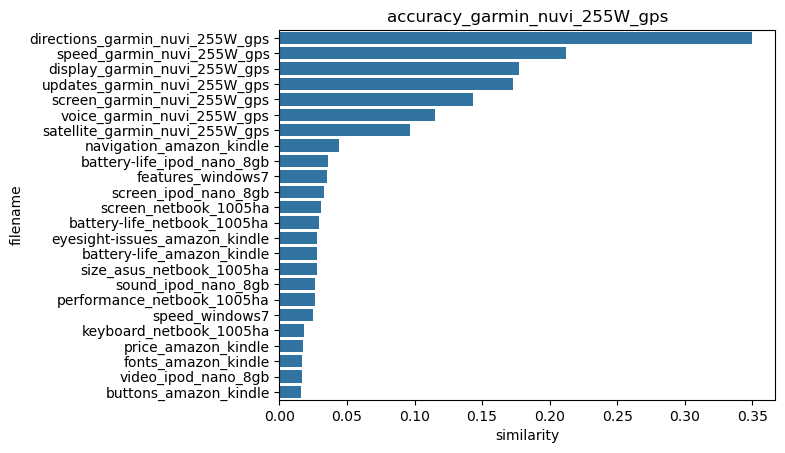

In [38]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

sorted_index = similarity_pair.argsort()[:, ::-1]
sorted_index = sorted_index[:, 1:]

hotel_sorted_indexes = hotel_indexes[sorted_index.reshape(-1)]

hotel_1_sim_value = np.sort(similarity_pair.reshape(-1))[::-1]
hotel_1_sim_value = hotel_1_sim_value[1:]

hotel_1_sim_df = pd.DataFrame()
hotel_1_sim_df['filename'] = document_df.iloc[hotel_sorted_indexes]['filename'].values
hotel_1_sim_df['similarity'] = hotel_1_sim_value

print('가장 유사도가 큰 파일명 및 유사도:\n', hotel_1_sim_df.iloc[0, :])

sns.barplot(x='similarity', y='filename', data=hotel_1_sim_df)
plt.title(comparison_docname)
plt.show()